In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
#Load Dataset
df = pd.read_csv("phishing_dataset.csv")

df.head()

,url,url_length,num_dots,num_hyphens,num_at,num_question,num_equal,num_slash,https,has_ip,suspicious_word,num_digits,num_subdomains,label
0,https://www.twitter.co,22,2,0,0,0,0,2,1,0,0,0,1,0
1,http://confirm557-twitter.net,29,1,1,0,0,0,2,0,0,1,3,0,1
2,https://www.netflix.in,22,2,0,0,0,0,2,1,0,0,0,1,0
3,http://confirm-microsoft.in,27,1,1,0,0,0,2,0,0,1,0,0,1
4,https://www.linkedin.net,24,2,0,0,0,0,2,1,0,0,0,1,0


In [18]:
df.shape

(20000, 14)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   url              20000 non-null  object
 1   url_length       20000 non-null  int64 
 2   num_dots         20000 non-null  int64 
 3   num_hyphens      20000 non-null  int64 
 4   num_at           20000 non-null  int64 
 5   num_question     20000 non-null  int64 
 6   num_equal        20000 non-null  int64 
 7   num_slash        20000 non-null  int64 
 8   https            20000 non-null  int64 
 9   has_ip           20000 non-null  int64 
 10  suspicious_word  20000 non-null  int64 
 11  num_digits       20000 non-null  int64 
 12  num_subdomains   20000 non-null  int64 
 13  label            20000 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 2.1+ MB


In [20]:
df.isnull().sum()

url                0
url_length         0
num_dots           0
num_hyphens        0
num_at             0
num_question       0
num_equal          0
num_slash          0
https              0
has_ip             0
suspicious_word    0
num_digits         0
num_subdomains     0
label              0
dtype: int64

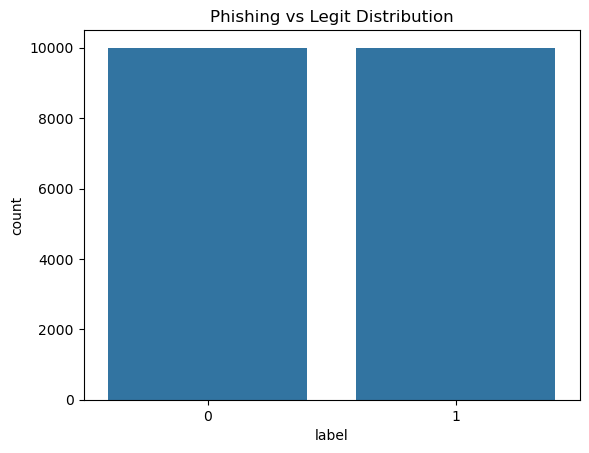

In [21]:
#EDA (Exploratory Data Analysis)
#1️Class Distribution
sns.countplot(x="label", data=df)
plt.title("Phishing vs Legit Distribution")
plt.show()

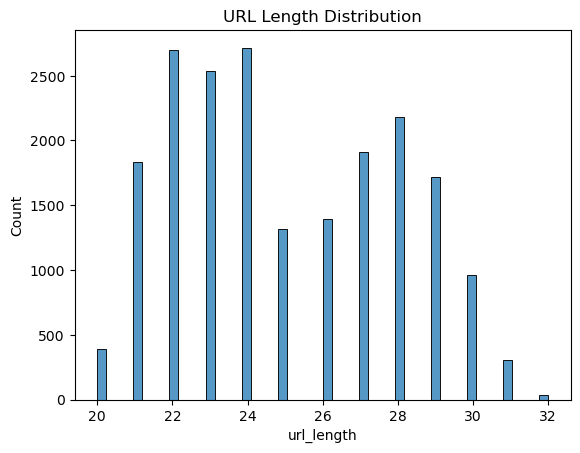

In [22]:
#URL Length Distribution
sns.histplot(df["url_length"], bins=50)
plt.title("URL Length Distribution")
plt.show()

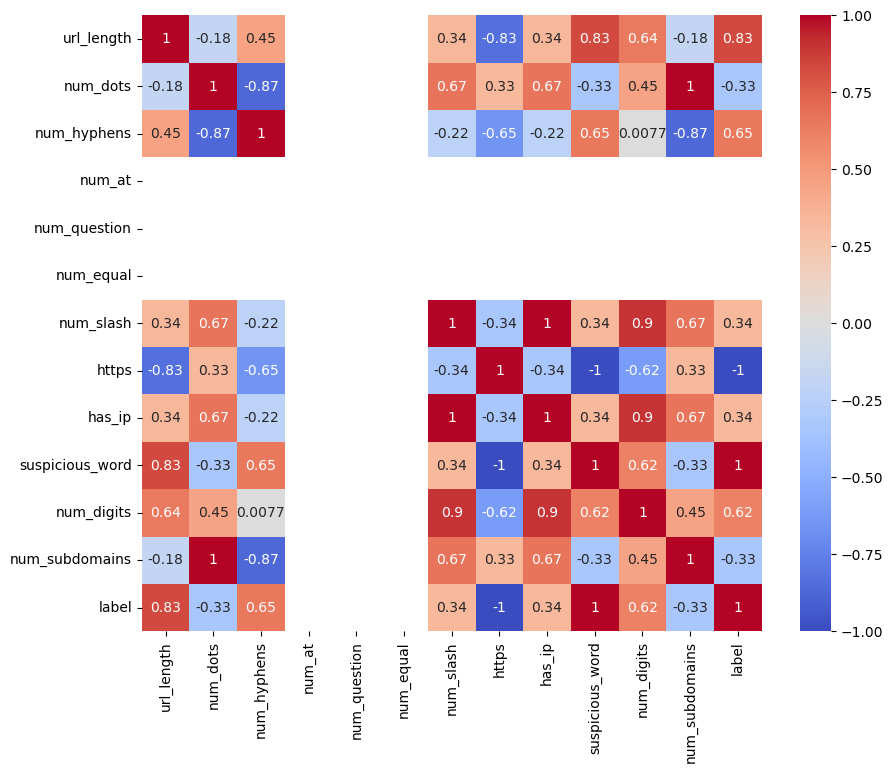

In [23]:
#Correlation Heatmap
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

#EXISTING MODEL → MACHINE LEARNING (RF)

In [24]:
#ML Preprocessing
X = df.drop(["url","label"], axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Weak Random Forest to reduce accuracy
rf = RandomForestClassifier(
    n_estimators=1,        # only one tree
    max_depth=1,           # very shallow tree (decision stump)
    max_features=1,        # use only one feature per split
    min_samples_split=100,
    min_samples_leaf=100,
    bootstrap=False,
    random_state=12
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)*100

print(f"RF Accuracy: {acc_rf:.2f}%")
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 89.88%
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      2026
           1       1.00      0.79      0.89      1974

    accuracy                           0.90      4000
   macro avg       0.92      0.90      0.90      4000
weighted avg       0.92      0.90      0.90      4000



In [55]:
#Save ML Model
joblib.dump(rf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

#PROPOSED DL MODEL → CNN + BiLSTM

In [30]:
#Text Preprocessing
urls = df["url"]
labels = df["label"]

tokenizer = Tokenizer(num_words=10000, char_level=True)
tokenizer.fit_on_texts(urls)

sequences = tokenizer.texts_to_sequences(urls)
max_length = 120

padded = pad_sequences(sequences, maxlen=max_length, padding='post')

X_train, X_test, y_train, y_test = train_test_split(
    padded, labels, test_size=0.2, random_state=42)

In [31]:
#Build CNN-BiLSTM Model
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=10000, output_dim=128, input_length=max_length))

# CNN Layer
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

# BiLSTM Layer
model.add(Bidirectional(LSTM(64)))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
#Train Model
early_stop = EarlyStopping(monitor='val_loss', patience=2)

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.9714 - loss: 0.1055 - val_accuracy: 1.0000 - val_loss: 4.8197e-04
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 1.0000 - loss: 5.6786e-04 - val_accuracy: 1.0000 - val_loss: 1.7788e-04
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 1.0000 - loss: 2.9493e-04 - val_accuracy: 1.0000 - val_loss: 1.0062e-04
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 1.0000 - loss: 1.9349e-04 - val_accuracy: 1.0000 - val_loss: 6.7945e-05
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 1.0000 - loss: 1.5124e-04 - val_accuracy: 1.0000 - val_loss: 4.9723e-05
Epoch 6/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 1.0000 - loss: 1.1186e-04 - val_accuracy: 1.0000 - val_loss: 3.8956e-05
Epoch 7/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 1.0000 - loss: 9.5821e-05 - val_accuracy: 1.0000 - val_loss: 3.1270e-05
Epoch 8/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/ste

In [57]:
#Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
accuracy_dl = accuracy*100
print(f"CNN-BiLSTM Accuracy: {accuracy_dl:.2f}%")

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 1.0000 - loss: 2.5452e-05
CNN-BiLSTM Accuracy: 100.00%
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step   
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2026
           1       1.00      1.00      1.00      1974

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



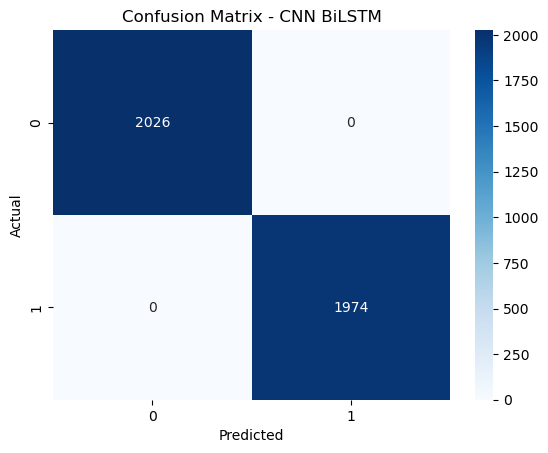

In [34]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - CNN BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
#Save Model
model.save("cnn_bilstm_phishing_model.h5")
joblib.dump(tokenizer, "tokenizer_cnn.pkl")

['tokenizer_cnn.pkl']

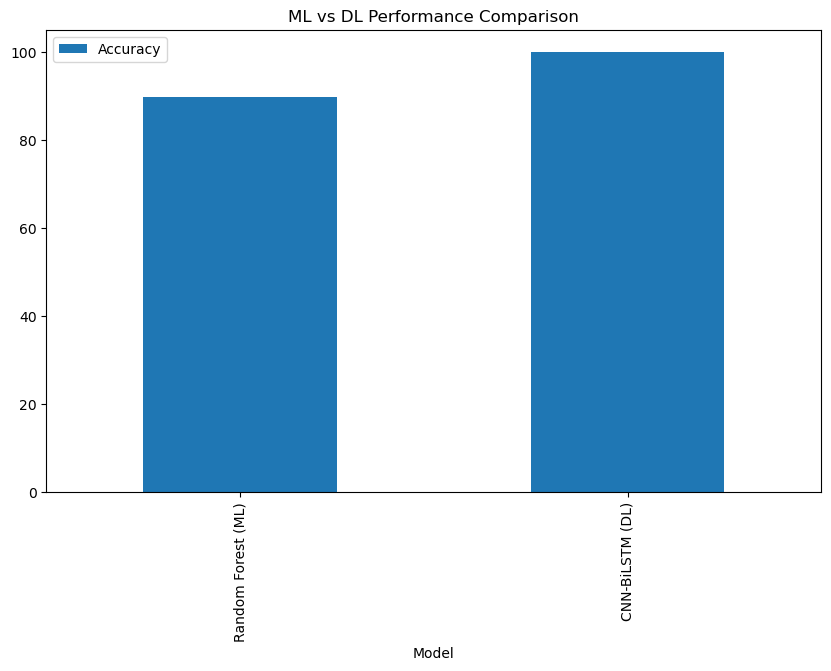

In [62]:

comparison_df = pd.DataFrame({
    "Model": ["Random Forest (ML)", "CNN-BiLSTM (DL)"],
    "Accuracy": [acc_rf, accuracy_dl],
})

comparison_df.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("ML vs DL Performance Comparison")
plt.show()

In [ ]:
import plotly.express as px

models = pd.DataFrame({
    'Model' : ["Random Forest (ML)", "CNN-BiLSTM (DL)"],
    'Score' : [acc_test_log,acc_test_knn,acc_test_tree,acc_test_forest]
})
models.sort_values(by = 'Score', ascending = False)


px.bar(data_frame = models, x = 'Score', y = 'Model', color = 'Score', template = 'plotly_dark', 
       title = 'Models Comparison')

In [44]:
# ============================================
# PHISHING URL DETECTION - DL PREDICTION
# CNN-BiLSTM Model
# ============================================

import joblib
import re
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================
# LOAD SAVED MODEL & TOKENIZER
# ============================================

print("Loading Model...")

model = load_model("cnn_bilstm_phishing_model.h5")
tokenizer = joblib.load("tokenizer_cnn.pkl")

max_length = 120

print("Model Loaded Successfully!\n")


# ============================================
# PREDICTION FUNCTION
# ============================================

def predict_url(url):
    
    # Basic cleaning
    url = url.strip()
    
    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([url])
    
    # Pad sequence
    padded = pad_sequences(sequence, maxlen=max_length, padding='post')
    
    # Predict
    prediction = model.predict(padded, verbose=0)
    
    probability = float(prediction[0][0])
    
    if probability > 0.5:
        result = "⚠️ PHISHING URL"
    else:
        result = "✅ LEGITIMATE URL"
    
    return result, probability


# ============================================
# CONTINUOUS USER INPUT LOOP
# ============================================

while True:
    
    print("\n-----------------------------------")
    user_url = input("Enter Website URL (or type 'exit'): ")
    
    if user_url.lower() == "exit":
        print("Exiting Program...")
        break
    
    result, prob = predict_url(user_url)
    
    print("\nPrediction Result:", result)
    print("Confidence Score:", round(prob * 100, 2), "%")
    print("-----------------------------------")

Loading Model...


Model Loaded Successfully!


-----------------------------------


Enter Website URL (or type 'exit'):  https://web.whatsapp.com/



Prediction Result: ✅ LEGITIMATE URL
Confidence Score: 0.02 %
-----------------------------------

-----------------------------------


Enter Website URL (or type 'exit'):  https://darknetdiaries.com/



Prediction Result: ⚠️ PHISHING URL
Confidence Score: 100.0 %
-----------------------------------

-----------------------------------


Enter Website URL (or type 'exit'):  exit


Exiting Program...
